In [ ]:
from collections import Counter
import os
import glob
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from torch.utils.data import random_split, DataLoader
from torchinfo import summary
from tqdm import tqdm

from session_image_dataset import SessionImageDataset
from arch import ATVITSC

In [ ]:
# Configuration
EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.001
TRAIN_SPLIT = 0.8
M_SIZE = 256
N_SIZE = 16

BENIGN_PCAP_PATHS = [
    "archive/Benign/BitTorrent.pcap",
    "archive/Benign/Facetime.pcap",
    "archive/Benign/Gmail.pcap",
    "archive/Benign/Outlook.pcap",
    "archive/Benign/Skype.pcap",
    "archive/Benign/WorldOfWarcraft.pcap",
]

MALWARE_PCAP_PATHS = [
    "archive/Malware/Miuref.pcap",
    "archive/Malware/Tinba.pcap",
    "archive/Malware/Zeus.pcap",
]

PCAP_PATHS = BENIGN_PCAP_PATHS + MALWARE_PCAP_PATHS
PCAP_LABELS = [0] * len(BENIGN_PCAP_PATHS) + [1] * len(MALWARE_PCAP_PATHS)

SAVE_DIR = "checkpoints/benign-malware"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# Load dataset
dataset = SessionImageDataset(PCAP_PATHS, PCAP_LABELS, m=M_SIZE, n=N_SIZE)

class_counts = Counter(dataset.labels)
print(class_counts)

Loading archive/Benign/BitTorrent.pcap
Grouping packets by session


Creating session images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7517/7517 [00:00<00:00, 17077.81it/s]


Loaded 7517 sessions from archive/Benign/BitTorrent.pcap
Loading archive/Benign/Facetime.pcap
Grouping packets by session


Creating session images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 22181.01it/s]


Loaded 6000 sessions from archive/Benign/Facetime.pcap
Loading archive/Benign/Gmail.pcap
Grouping packets by session


...

Loaded 13478 sessions from archive/Malware/Miuref.pcap
Loading archive/Malware/Tinba.pcap
Grouping packets by session


Creating session images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8503/8503 [00:00<00:00, 17121.99it/s]


Loaded 8503 sessions from archive/Malware/Tinba.pcap
Loading archive/Malware/Zeus.pcap
Grouping packets by session


Creating session images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10970/10970 [00:01<00:00, 10639.95it/s]

Loaded 10970 sessions from archive/Malware/Zeus.pcap
Counter({0: 43874, 1: 32951})


In [ ]:
# Split dataset
train_size = int(TRAIN_SPLIT * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train size: {train_size}")
print(f"Val   size: {val_size}")

Train size: 61460
Val   size: 15365


In [ ]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate model, optimizer, and criterion
model = ATVITSC(num_classes=len(class_counts))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.CrossEntropyLoss()

summary(model, input_data=[torch.randn(BATCH_SIZE, 1, 64, 64), torch.randint(0, 1502, (BATCH_SIZE, 16))])

Using device: cuda


Layer (type:depth-idx)                                       Output Shape              Param #
ATVITSC                                                      [64, 2]                   --
├─PVT: 1-1                                                   [64, 256]                 4,865
│    └─ViT: 2-3                                              --                        (recursive)
│    │    └─Sequential: 3-1                                  [64, 16, 256]             66,816
│    └─Embedding: 2-2                                        [64, 16, 256]             384,512
│    └─ViT: 2-3                                              --                        (recursive)
│    │    └─Transformer: 3-2                                 [64, 17, 256]             3,677,696
│    │    └─Identity: 3-3                                    [64, 256]                 --
├─STFE: 1-2                                                  [64, 256]                 --
│    └─ResAtConv: 2-4                                     

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=10, save_dir="checkpoints"):
    model.to(device)

    start_epoch = 0
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': [],
    }

    os.makedirs(save_dir, exist_ok=True)
    checkpoint_paths = glob.glob(os.path.join(save_dir, "model_epoch_*.pth"))
    if checkpoint_paths:
        latest_checkpoint = max(checkpoint_paths, key=lambda x: int(os.path.basename(x).split('_')[2].split('.')[0]))
        print(f"Loading checkpoint: {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
        history = checkpoint['history']
        print(f"Resuming training from epoch {start_epoch + 1}")

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for images, packet_lens, labels in loop:
            # images: (B, H, W) -> (B, 1, H, W)
            if images.ndim == 3:
                images = images.unsqueeze(1)

            images = images.to(device).float()
            packet_lens = packet_lens.to(device).long()
            labels = labels.to(device).long()

            optimizer.zero_grad()
            outputs = model(images, packet_lens)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            loop.set_postfix(loss=train_loss/train_total, acc=train_correct/train_total)

        epoch_train_loss = train_loss / train_total
        history['train_loss'].append(epoch_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_total = 0

        all_labels = []
        all_preds = []
        all_probs = []

        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
            for images, packet_lens, labels in val_loop:
                if images.ndim == 3:
                    images = images.unsqueeze(1)

                images = images.to(device).float()
                packet_lens = packet_lens.to(device).long()
                labels = labels.to(device).long()

                outputs = model(images, packet_lens)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_total += images.size(0)

                _, predicted = outputs.max(1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                val_loop.set_postfix(loss=val_loss/val_total)

        epoch_val_loss = val_loss / val_total
        history['val_loss'].append(epoch_val_loss)

        # Calculate metrics
        val_acc = accuracy_score(all_labels, all_preds)
        val_prec = precision_score(all_labels, all_preds, average='weighted')
        val_rec = recall_score(all_labels, all_preds, average='weighted')
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        val_cm = confusion_matrix(all_labels, all_preds)

        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_prec)
        history['val_recall'].append(val_rec)
        history['val_f1'].append(val_f1)
        print(f"\nEpoch {epoch+1}/{epochs} Results:")
        print(f"Train Loss: {epoch_train_loss:.4f}")
        print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f} | Precision: {val_prec:.4f} | Recall: {val_rec:.4f} | F1: {val_f1:.4f}")
        if val_cm is not None:
            print(f"Confusion Matrix:\n{val_cm}\n")

        # Save model and training state after each epoch
        save_path = os.path.join(save_dir, f"model_epoch_{epoch+1}.pth")
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history
        }
        torch.save(checkpoint, save_path)

    return history

In [ ]:
# Start training
history = train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=EPOCHS, save_dir=SAVE_DIR)

Epoch 1/10 [Val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 241/241 [00:01<00:00, 233.12it/s, loss=0.00796]



Epoch 1/10 Results:
Train Loss: 0.0163
Val Loss:   0.0080 | Val Acc: 0.9979 | Precision: 0.9979 | Recall: 0.9979 | F1: 0.9979
Confusion Matrix:
[[8809    0]
 [  32 6524]]



Epoch 2/10 [Val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 241/241 [00:00<00:00, 255.19it/s, loss=0.00583]



Epoch 2/10 Results:
Train Loss: 0.0061
Val Loss:   0.0058 | Val Acc: 0.9979 | Precision: 0.9979 | Recall: 0.9979 | F1: 0.9979
Confusion Matrix:
[[8809    0]
 [  32 6524]]



Epoch 3/10 [Val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 241/241 [00:00<00:00, 251.70it/s, loss=0.00495]


...


Epoch 8/10 Results:
Train Loss: 0.0043
Val Loss:   0.0044 | Val Acc: 0.9980 | Precision: 0.9980 | Recall: 0.9980 | F1: 0.9980
Confusion Matrix:
[[8809    0]
 [  31 6525]]



Epoch 9/10 [Val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 241/241 [00:00<00:00, 256.44it/s, loss=0.00458]



Epoch 9/10 Results:
Train Loss: 0.0044
Val Loss:   0.0046 | Val Acc: 0.9980 | Precision: 0.9980 | Recall: 0.9980 | F1: 0.9980
Confusion Matrix:
[[8809    0]
 [  31 6525]]



Epoch 10/10 [Val]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 241/241 [00:00<00:00, 259.56it/s, loss=0.02]



Epoch 10/10 Results:
Train Loss: 0.0054
Val Loss:   0.0200 | Val Acc: 0.9954 | Precision: 0.9955 | Recall: 0.9954 | F1: 0.9954
Confusion Matrix:
[[8740   69]
 [   1 6555]]



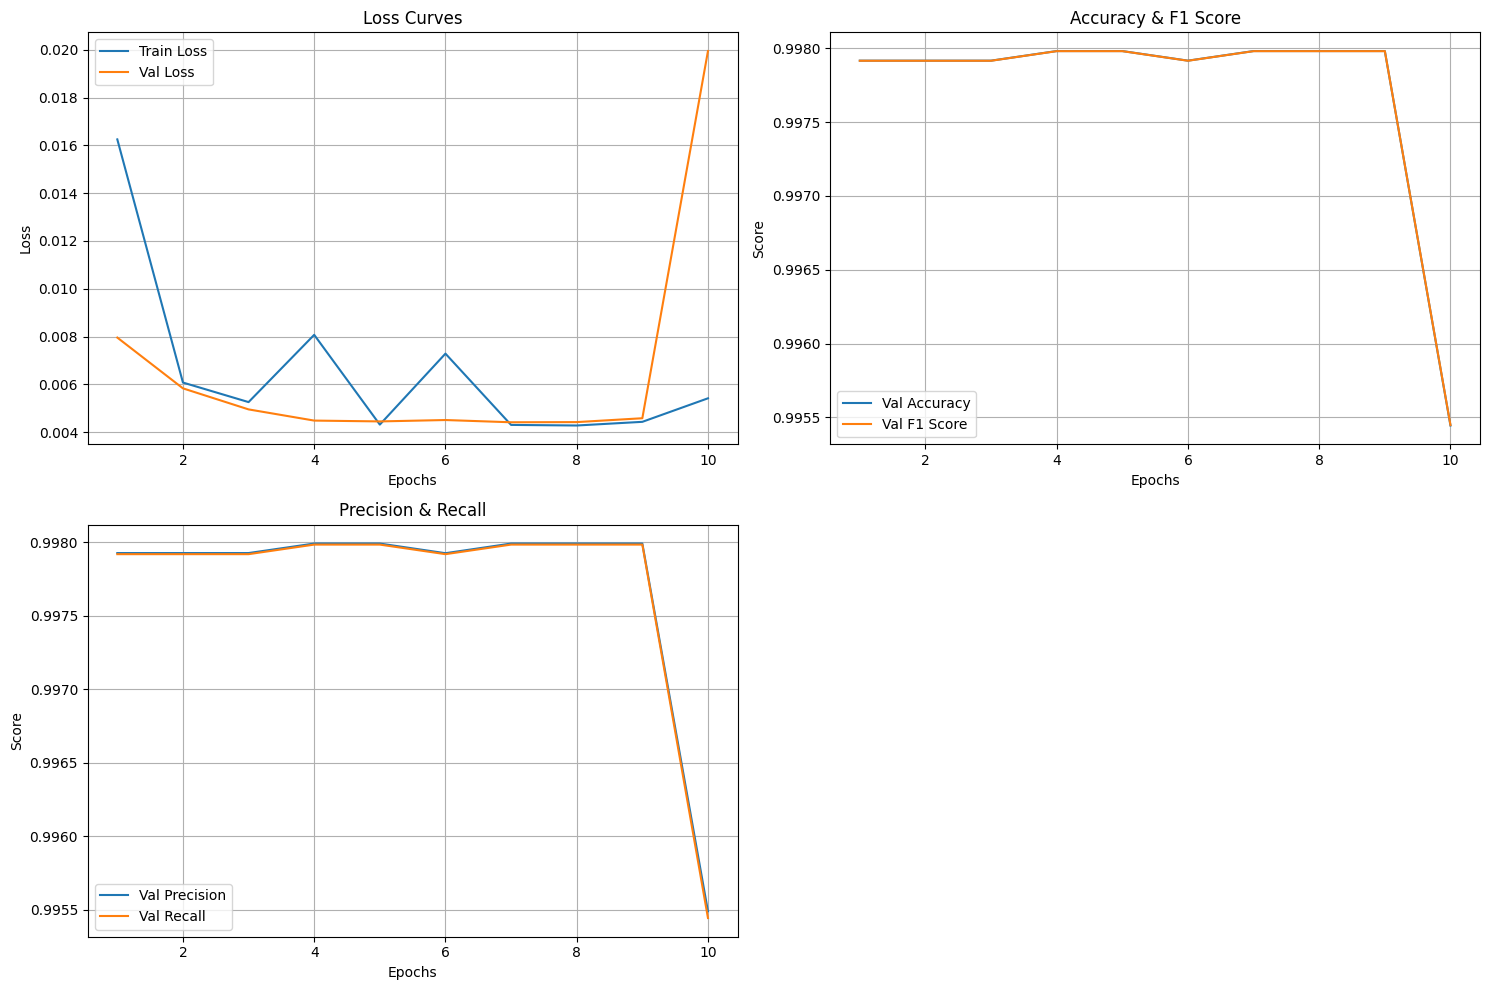

In [ ]:
# Plotting
def plot_metrics(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 10))

    # Plot Losses
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy & F1
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['val_acc'], label='Val Accuracy')
    plt.plot(epochs, history['val_f1'], label='Val F1 Score')
    plt.title('Accuracy & F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    # Plot Precision & Recall
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['val_precision'], label='Val Precision')
    plt.plot(epochs, history['val_recall'], label='Val Recall')
    plt.title('Precision & Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(history)